# ML Experiment: Corrected Out-of-Sample t-SNE for Classification

This notebook evaluates whether the corrected out-of-sample t-SNE embeddings provide useful input features for the four machine-learning tasks defined in `ml_classification_experiment.ipynb`:

- **Task A:** phase classification, with labels $\phi = i \bmod 20$.
- **Task B:** actuation Strouhal-number classification, with one class per forced run.
- **Task C:** joint multi-output prediction of $(\phi, St_{act})$.
- **Task D:** generalization to unseen actuation frequencies, using the leave-frequencies-out split.

Two out-of-sample projections are compared while keeping the same fitted training t-SNE embedding:

1. **KL t-SNE:** each test point is optimized against a globally normalized t-SNE objective.
2. **k-NN t-SNE:** each test point is placed by inverse-distance-weighted interpolation from high-dimensional nearest neighbours.

The notebook stores the resulting model metrics in `ml_results/` and stores the reusable train/test t-SNE embeddings in `tsne_data/`.

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os, sys, time, importlib

sys.path.append(os.path.abspath('.'))
import ml_experiment_utils as mlu
importlib.reload(mlu)

plt.rc('text', usetex=False)
plt.rc('font', family='serif', size=12)

os.makedirs('figures', exist_ok=True)
os.makedirs('tsne_data', exist_ok=True)
os.makedirs('ml_results', exist_ok=True)

print('Setup complete.')

Setup complete.


## 1. Data and Labels

The experiment starts from `pca_data/global_forced_pca.npz`, which contains a 500-dimensional global PCA representation of all forced PIV snapshots. This avoids reloading the original velocity fields while preserving the dominant variance structure of the concatenated fluctuation field

$$
\mathbf{x}_i = [u_i(x_1,y_1), \ldots, u_i(x_M,y_M), v_i(x_1,y_1), \ldots, v_i(x_M,y_M)].
$$

The labels are inherited from the acquisition protocol: $St_{act}$ is fixed for each run, and the phase label is the snapshot index modulo the 20 snapshots per actuation cycle.

In [39]:
# Load the global PCA scores used throughout the ML experiments.
data = np.load('pca_data/global_forced_pca.npz')
pca_scores   = data['pca_scores']     # Shape: (48720, 500)
run_labels   = data['run_labels']     # Forced run ID for each snapshot.
st_labels    = data['st_labels']      # Actuation Strouhal number for each snapshot.
phase_labels = data['phase_labels']   # Phase index in {0, ..., 19}.

print(f'PCA scores shape: {pca_scores.shape}')
print(f'Forced runs: {np.unique(run_labels)}')
print(f'Number of St_act classes: {len(np.unique(st_labels))}')
print(f'Phase labels: {np.unique(phase_labels)}')

PCA scores shape: (48720, 500)
Forced runs: [ 2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25]
Number of St_act classes: 24
Phase labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]


## 2. Train/Test Splits

The same splits as the baseline ML notebook are used so that the comparison is controlled.

For Tasks A--C, a stratified random split preserves the joint distribution of $(St_{act}, \phi)$ between train and test sets. For Task D, the model is trained on all snapshots except Runs 4, 10, 16, and 22, then evaluated on those held-out frequencies. This second split tests interpolation across actuation conditions rather than interpolation between snapshots from the same run.

In [40]:
# Standard split for Tasks A, B, and C.
std_train_idx, std_test_idx = mlu.create_standard_split(
    pca_scores, phase_labels, st_labels
)

# Leave-frequencies-out split for Task D.
lfo_train_idx, lfo_test_idx = mlu.create_leave_freq_out_split(run_labels)
held_out_st = [mlu.ST_INFO[run] for run in mlu.HELD_OUT_RUNS]

print(f'Standard split: {len(std_train_idx)} train, {len(std_test_idx)} test')
print(f'Leave-freq-out split: {len(lfo_train_idx)} train, {len(lfo_test_idx)} test')
print(f'Held-out St_act values: {held_out_st}')

Standard split: 38976 train, 9744 test
Leave-freq-out split: 40600 train, 8120 test
Held-out St_act values: [0.15, 0.45, 0.75, 1.05]


## 3. Out-of-Sample t-SNE Embeddings

A t-SNE map is not a parametric transformation: after fitting the training embedding $\mathbf{Y}_{train}$, there is no native function $f(\mathbf{x})$ that maps a new PIV snapshot into the same low-dimensional coordinates. The two projections below approximate such a map without fitting t-SNE on the test set.

For the KL projection, a test point $\mathbf{y}$ is optimized while all training coordinates remain fixed. Its high-dimensional affinities $p_j$ are nonzero only for its nearest neighbours, but its low-dimensional affinities

$$
q_j(\mathbf{y}) = \frac{(1 + \|\mathbf{y} - \mathbf{y}_j\|^2)^{-1}}{\sum_{m \in train} (1 + \|\mathbf{y} - \mathbf{y}_m\|^2)^{-1}}
$$

are normalized over the full training embedding. This global denominator restores the repulsive term that was missing in the failed embedding. The k-NN projection is simpler: it computes an inverse-distance-weighted average of the nearest training t-SNE coordinates.

In [41]:
# Configuration chosen to match the previous t-SNE experiments while giving
# the KL projection enough neighbours to realize perplexity 50.
TSNE_PERPLEXITY = 50
TSNE_COMPONENTS = 3
KL_NEIGHBORS = 75
KNN_NEIGHBORS = 10
EMBEDDING_PATH = 'tsne_data/ml_tsne_oos_embeddings.npz'


def compute_or_load_tsne_embeddings():
    """Load cached embeddings, or compute and save them if absent."""
    if os.path.exists(EMBEDDING_PATH):
        print(f'Loading cached t-SNE embeddings from {EMBEDDING_PATH}...')
        cached = np.load(EMBEDDING_PATH)
        return {key: cached[key] for key in cached.files}

    embeddings = {}
    timings = {}

    # Fit t-SNE only on the standard training split.
    std_train = pca_scores[std_train_idx]
    std_test = pca_scores[std_test_idx]
    embeddings['std_train'], timings['std_fit_time'] = mlu.fit_tsne_embedding(
        std_train,
        n_components=TSNE_COMPONENTS,
        perplexity=TSNE_PERPLEXITY,
        random_state=mlu.RANDOM_STATE
    )

    # Project the same standard test set with both out-of-sample methods.
    t0 = time.time()
    embeddings['std_test_kl'] = mlu.embed_new_points_kl(
        std_train,
        embeddings['std_train'],
        std_test,
        k=KL_NEIGHBORS,
        perplexity=TSNE_PERPLEXITY
    )
    timings['std_kl_time'] = time.time() - t0

    t0 = time.time()
    embeddings['std_test_knn'] = mlu.embed_new_points_knn(
        std_train,
        embeddings['std_train'],
        std_test,
        k=KNN_NEIGHBORS
    )
    timings['std_knn_time'] = time.time() - t0

    # Repeat the same procedure for the leave-frequencies-out split.
    lfo_train = pca_scores[lfo_train_idx]
    lfo_test = pca_scores[lfo_test_idx]
    embeddings['lfo_train'], timings['lfo_fit_time'] = mlu.fit_tsne_embedding(
        lfo_train,
        n_components=TSNE_COMPONENTS,
        perplexity=TSNE_PERPLEXITY,
        random_state=mlu.RANDOM_STATE
    )

    t0 = time.time()
    embeddings['lfo_test_kl'] = mlu.embed_new_points_kl(
        lfo_train,
        embeddings['lfo_train'],
        lfo_test,
        k=KL_NEIGHBORS,
        perplexity=TSNE_PERPLEXITY
    )
    timings['lfo_kl_time'] = time.time() - t0

    t0 = time.time()
    embeddings['lfo_test_knn'] = mlu.embed_new_points_knn(
        lfo_train,
        embeddings['lfo_train'],
        lfo_test,
        k=KNN_NEIGHBORS
    )
    timings['lfo_knn_time'] = time.time() - t0

    # Store the embeddings and configuration so the ML tasks can be rerun
    # without paying the t-SNE fitting cost again.
    np.savez_compressed(
        EMBEDDING_PATH,
        **embeddings,
        **{key: np.array(value) for key, value in timings.items()},
        tsne_perplexity=np.array(TSNE_PERPLEXITY),
        kl_neighbors=np.array(KL_NEIGHBORS),
        knn_neighbors=np.array(KNN_NEIGHBORS)
    )
    print(f'Saved embeddings to {EMBEDDING_PATH}')
    return embeddings | {key: np.array(value) for key, value in timings.items()}


emb = compute_or_load_tsne_embeddings()

print('Available arrays:')
for key in sorted(emb):
    if hasattr(emb[key], 'shape'):
        print(f'  {key}: {emb[key].shape}')

Fitting sklearn TSNE (n_components=3, perplexity=50) on 38976 samples with 500 features...
  Fitting completed in 8.9 minutes.
Finding 75-NN for 9744 test points...
    Embedded 2000/9744 test points...
    Embedded 4000/9744 test points...
    Embedded 6000/9744 test points...
    Embedded 8000/9744 test points...
Finding 10-NN for 9744 test points in high-dimensional space...
  k-NN interpolation completed in 2.9 seconds.
Fitting sklearn TSNE (n_components=3, perplexity=50) on 40600 samples with 500 features...
  Fitting completed in 13.3 minutes.
Finding 75-NN for 8120 test points...
    Embedded 2000/8120 test points...
    Embedded 4000/8120 test points...
    Embedded 6000/8120 test points...
    Embedded 8000/8120 test points...
Finding 10-NN for 8120 test points in high-dimensional space...
  k-NN interpolation completed in 2.4 seconds.
Saved embeddings to tsne_data/ml_tsne_oos_embeddings.npz
Available arrays:
  lfo_fit_time: ()
  lfo_kl_time: ()
  lfo_knn_time: ()
  lfo_test_k

## 4. Embedding Diagnostics

Before training models, the train and test coordinate scales are compared. A corrected out-of-sample embedding should place test points inside the same coordinate range as the fixed training t-SNE map. If the test standard deviation or coordinate range is orders of magnitude larger than the training one, the old exploding-cloud failure has reappeared and the ML metrics should not be interpreted.

In [42]:
# Quantify whether each out-of-sample projection occupies the same coordinate
# scale as the corresponding training embedding.
diagnostic_rows = []
for split_name in ['std', 'lfo']:
    train_key = f'{split_name}_train'
    for method_name, test_key in [('KL', f'{split_name}_test_kl'),
                                  ('k-NN', f'{split_name}_test_knn')]:
        train = emb[train_key]
        test = emb[test_key]
        diagnostic_rows.append({
            'split': split_name,
            'method': method_name,
            'train_std_mean': train.std(axis=0).mean(),
            'test_std_mean': test.std(axis=0).mean(),
            'std_ratio_test_over_train': test.std(axis=0).mean() / train.std(axis=0).mean(),
            'train_range_mean': (train.max(axis=0) - train.min(axis=0)).mean(),
            'test_range_mean': (test.max(axis=0) - test.min(axis=0)).mean(),
        })

df_diag = pd.DataFrame(diagnostic_rows)
display(df_diag.round(4))

,split,method,train_std_mean,test_std_mean,std_ratio_test_over_train,train_range_mean,test_range_mean
0,std,KL,18.448601,18.1232,0.9824,93.708298,95.8303
1,std,k-NN,18.448601,17.0980,0.9268,93.708298,88.8502
2,lfo,KL,19.669600,44.7314,2.2741,96.235397,3482.7091
3,lfo,k-NN,19.669600,16.5663,0.8422,96.235397,80.9019


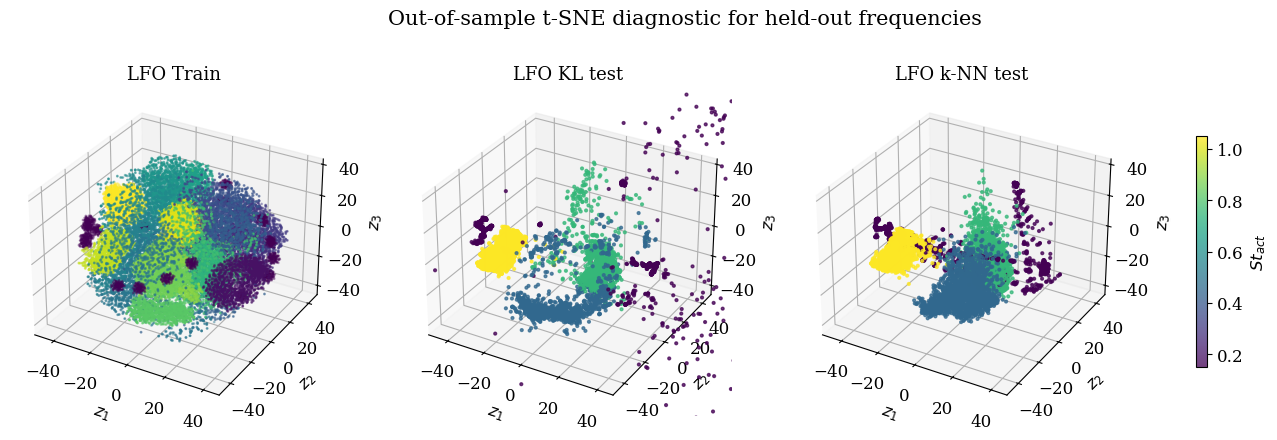

In [43]:
# Visual diagnostic for the harder leave-frequencies-out split.
fig, axes = plt.subplots(1, 3, figsize=(18, 5), subplot_kw={'projection': '3d'})
plot_specs = [
    ('Train', emb['lfo_train'], st_labels[lfo_train_idx], 1.0, 0.35),
    ('KL test', emb['lfo_test_kl'], st_labels[lfo_test_idx], 4.0, 0.75),
    ('k-NN test', emb['lfo_test_knn'], st_labels[lfo_test_idx], 4.0, 0.75),
]

for ax, (title, coords, color, size, alpha) in zip(axes, plot_specs):
    sc = ax.scatter(
        coords[:, 0], coords[:, 1], coords[:, 2],
        c=color, cmap='viridis', s=size, alpha=alpha
    )
    ax.set_title(f'LFO {title}', fontsize=13)
    ax.set_xlabel('$z_1$', fontsize=12)
    ax.set_ylabel('$z_2$', fontsize=12)
    ax.set_zlabel('$z_3$', fontsize=12)

    # Identical limits make scale failures immediately visible.
    ax.set_xlim(emb['lfo_train'][:, 0].min(), emb['lfo_train'][:, 0].max())
    ax.set_ylim(emb['lfo_train'][:, 1].min(), emb['lfo_train'][:, 1].max())
    ax.set_zlim(emb['lfo_train'][:, 2].min(), emb['lfo_train'][:, 2].max())

fig.colorbar(sc, ax=axes, shrink=0.6, label='$St_{act}$')
fig.suptitle('Out-of-sample t-SNE diagnostic for held-out frequencies', fontsize=15)
plt.savefig('figures/tsne_oos_lfo_diagnostic.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Tasks A, B, and C: Standard Split

The Random Forest models are trained on the 3D t-SNE coordinates of the standard training split and evaluated on standard test coordinates produced by either KL optimization or k-NN interpolation. Because both train and test samples come from the same set of actuation frequencies, strong performance here indicates that the embedding preserves discriminative information locally within the sampled frequency manifold.

In [44]:
# Build the two t-SNE representations for the standard split.
std_reps = {
    't-SNE-KL-3D':  (emb['std_train'], emb['std_test_kl']),
    't-SNE-kNN-3D': (emb['std_train'], emb['std_test_knn']),
}

print('Running Tasks A, B, and C for corrected t-SNE representations...')
std_results = mlu.run_all_standard_experiments(
    std_reps,
    phase_labels[std_train_idx], phase_labels[std_test_idx],
    st_labels[std_train_idx], st_labels[std_test_idx]
)

df_std = pd.DataFrame(std_results)
df_std.to_csv('ml_results/ml_tsne_oos_standard_results.csv', index=False)
print('Saved standard-split results to ml_results/ml_tsne_oos_standard_results.csv')
display(df_std.round(4))

Running Tasks A, B, and C for corrected t-SNE representations...

  [t-SNE-KL-3D | Low]  A:0.162  B:0.569  C:0.116
  [t-SNE-KL-3D | Medium]  A:0.352  B:0.895  C:0.346
  [t-SNE-KL-3D | High]  A:0.351  B:0.900  C:0.343
  [t-SNE-kNN-3D | Low]  A:0.160  B:0.547  C:0.115
  [t-SNE-kNN-3D | Medium]  A:0.399  B:0.767  C:0.390
  [t-SNE-kNN-3D | High]  A:0.397  B:0.768  C:0.385
Done.
Saved standard-split results to ml_results/ml_tsne_oos_standard_results.csv


,task,representation,complexity,accuracy,f1_macro,train_time,inference_time,inference_time_per_sample,total_nodes,accuracy_phase,accuracy_st,f1_phase,f1_st,exact_match
0,A (Phase),t-SNE-KL-3D,Low,0.1619,0.1629,0.0649,0.0160,0.0000,554,NaN,NaN,NaN,NaN,NaN
1,B (St_act),t-SNE-KL-3D,Low,0.5694,0.5318,0.0783,0.0157,0.0000,526,NaN,NaN,NaN,NaN,NaN
2,C (Joint),t-SNE-KL-3D,Low,NaN,NaN,0.1265,0.0157,0.0000,598,0.1642,0.5788,0.1754,0.5310,0.1160
3,A (Phase),t-SNE-KL-3D,Medium,0.3519,0.3516,1.1429,0.0575,0.0000,1877506,NaN,NaN,NaN,NaN,NaN
4,B (St_act),t-SNE-KL-3D,Medium,0.8949,0.8932,0.9908,0.0836,0.0000,554856,NaN,NaN,NaN,NaN,NaN
5,C (Joint),t-SNE-KL-3D,Medium,NaN,NaN,1.7564,0.1220,0.0000,2118402,0.3530,0.8957,0.3527,0.8939,0.3455
6,A (Phase),t-SNE-KL-3D,High,0.3506,0.3503,6.5646,0.2896,0.0000,17355940,NaN,NaN,NaN,NaN,NaN
7,B (St_act),t-SNE-KL-3D,High,0.9002,0.8987,4.6579,0.2642,0.0000,3402588,NaN,NaN,NaN,NaN,NaN
8,C (Joint),t-SNE-KL-3D,High,NaN,NaN,11.6308,2.9293,0.0003,17790968,0.3491,0.9023,0.3488,0.9009,0.3430
9,A (Phase),t-SNE-kNN-3D,Low,0.1601,0.1627,0.0903,0.0167,0.0000,554,NaN,NaN,NaN,NaN,NaN


## 6. Task D: Generalization to Unseen Frequencies

Task D evaluates whether the 3D t-SNE coordinates support interpolation to actuation frequencies excluded from the training set. The first subtask treats $St_{act}$ as a continuous regression target, while the second asks whether phase labels transfer across frequencies. This split is the most relevant test of whether t-SNE provides a predictive coordinate system rather than only a visualization of known data.

In [45]:
# Build the two t-SNE representations for the leave-frequencies-out split.
lfo_reps = {
    't-SNE-KL-3D':  (emb['lfo_train'], emb['lfo_test_kl']),
    't-SNE-kNN-3D': (emb['lfo_train'], emb['lfo_test_knn']),
}

print('Running Task D for corrected t-SNE representations...')
gen_results = mlu.run_all_generalization_experiments(
    lfo_reps,
    phase_labels[lfo_train_idx], phase_labels[lfo_test_idx],
    st_labels[lfo_train_idx], st_labels[lfo_test_idx]
)

df_gen = pd.DataFrame(gen_results)
df_gen.to_csv('ml_results/ml_tsne_oos_generalization_results.csv', index=False)
print('Saved generalization results to ml_results/ml_tsne_oos_generalization_results.csv')
display(df_gen.round(4))

Running Task D for corrected t-SNE representations...

  [t-SNE-KL-3D | Low]  D1-R2:0.519  D2:0.064
  [t-SNE-KL-3D | Medium]  D1-R2:0.649  D2:0.028
  [t-SNE-KL-3D | High]  D1-R2:0.650  D2:0.027
  [t-SNE-kNN-3D | Low]  D1-R2:0.193  D2:0.065
  [t-SNE-kNN-3D | Medium]  D1-R2:0.051  D2:0.044
  [t-SNE-kNN-3D | High]  D1-R2:0.052  D2:0.043
Done.
Saved generalization results to ml_results/ml_tsne_oos_generalization_results.csv


,task,representation,complexity,mae,rmse,r2,train_time,inference_time,inference_time_per_sample,total_nodes,accuracy,f1_macro
0,D.1 (St regression),t-SNE-KL-3D,Low,0.1620,0.2327,0.5189,0.1362,0.0175,0.0,626,NaN,NaN
1,D.2 (Phase transfer),t-SNE-KL-3D,Low,NaN,NaN,NaN,0.0739,0.0166,0.0,530,0.0639,0.0468
2,D.1 (St regression),t-SNE-KL-3D,Medium,0.1346,0.1986,0.6494,2.0678,0.0501,0.0,296670,NaN,NaN
3,D.2 (Phase transfer),t-SNE-KL-3D,Medium,NaN,NaN,NaN,1.2797,0.0483,0.0,1558724,0.0280,0.0281
4,D.1 (St regression),t-SNE-KL-3D,High,0.1342,0.1985,0.6499,8.3264,0.1312,0.0,1643268,NaN,NaN
5,D.2 (Phase transfer),t-SNE-KL-3D,High,NaN,NaN,NaN,6.9133,0.2387,0.0,19027714,0.0267,0.0269
6,D.1 (St regression),t-SNE-kNN-3D,Low,0.2129,0.3014,0.1927,0.1466,0.0138,0.0,626,NaN,NaN
7,D.2 (Phase transfer),t-SNE-kNN-3D,Low,NaN,NaN,NaN,0.0726,0.0155,0.0,530,0.0651,0.0460
8,D.1 (St regression),t-SNE-kNN-3D,Medium,0.2297,0.3267,0.0510,2.0195,0.0360,0.0,296670,NaN,NaN
9,D.2 (Phase transfer),t-SNE-kNN-3D,Medium,NaN,NaN,NaN,1.1985,0.0473,0.0,1558724,0.0442,0.0433


## 7. Consolidated Result Storage and Figures

The final cells combine the two result tables, write one consolidated CSV file, and create compact figures for the thesis workflow. These files allow the t-SNE experiment to be compared directly with the PCA, SPCA, and KPCA result tables.

In [46]:
# Combine both evaluation regimes into a single long-format table.
df_std_labeled = df_std.copy()
df_std_labeled['split'] = 'standard'

df_gen_labeled = df_gen.copy()
df_gen_labeled['split'] = 'leave_freq_out'

df_all = pd.concat([df_std_labeled, df_gen_labeled], ignore_index=True)
df_all.to_csv('ml_results/ml_tsne_oos_all_results.csv', index=False)

# Store the diagnostic table separately because it describes embedding quality,
# not Random Forest model quality.
df_diag.to_csv('ml_results/ml_tsne_oos_embedding_diagnostics.csv', index=False)

print('Saved consolidated results to ml_results/ml_tsne_oos_all_results.csv')
print('Saved embedding diagnostics to ml_results/ml_tsne_oos_embedding_diagnostics.csv')
display(df_all.round(4))

Saved consolidated results to ml_results/ml_tsne_oos_all_results.csv
Saved embedding diagnostics to ml_results/ml_tsne_oos_embedding_diagnostics.csv


,task,representation,complexity,accuracy,f1_macro,train_time,inference_time,inference_time_per_sample,total_nodes,accuracy_phase,accuracy_st,f1_phase,f1_st,exact_match,split,mae,rmse,r2
0,A (Phase),t-SNE-KL-3D,Low,0.1619,0.1629,0.0649,0.0160,0.0000,554,NaN,NaN,NaN,NaN,NaN,standard,NaN,NaN,NaN
1,B (St_act),t-SNE-KL-3D,Low,0.5694,0.5318,0.0783,0.0157,0.0000,526,NaN,NaN,NaN,NaN,NaN,standard,NaN,NaN,NaN
2,C (Joint),t-SNE-KL-3D,Low,NaN,NaN,0.1265,0.0157,0.0000,598,0.1642,0.5788,0.1754,0.5310,0.1160,standard,NaN,NaN,NaN
3,A (Phase),t-SNE-KL-3D,Medium,0.3519,0.3516,1.1429,0.0575,0.0000,1877506,NaN,NaN,NaN,NaN,NaN,standard,NaN,NaN,NaN
4,B (St_act),t-SNE-KL-3D,Medium,0.8949,0.8932,0.9908,0.0836,0.0000,554856,NaN,NaN,NaN,NaN,NaN,standard,NaN,NaN,NaN
5,C (Joint),t-SNE-KL-3D,Medium,NaN,NaN,1.7564,0.1220,0.0000,2118402,0.3530,0.8957,0.3527,0.8939,0.3455,standard,NaN,NaN,NaN
6,A (Phase),t-SNE-KL-3D,High,0.3506,0.3503,6.5646,0.2896,0.0000,17355940,NaN,NaN,NaN,NaN,NaN,standard,NaN,NaN,NaN
7,B (St_act),t-SNE-KL-3D,High,0.9002,0.8987,4.6579,0.2642,0.0000,3402588,NaN,NaN,NaN,NaN,NaN,standard,NaN,NaN,NaN
8,C (Joint),t-SNE-KL-3D,High,NaN,NaN,11.6308,2.9293,0.0003,17790968,0.3491,0.9023,0.3488,0.9009,0.3430,standard,NaN,NaN,NaN
9,A (Phase),t-SNE-kNN-3D,Low,0.1601,0.1627,0.0903,0.0167,0.0000,554,NaN,NaN,NaN,NaN,NaN,standard,NaN,NaN,NaN


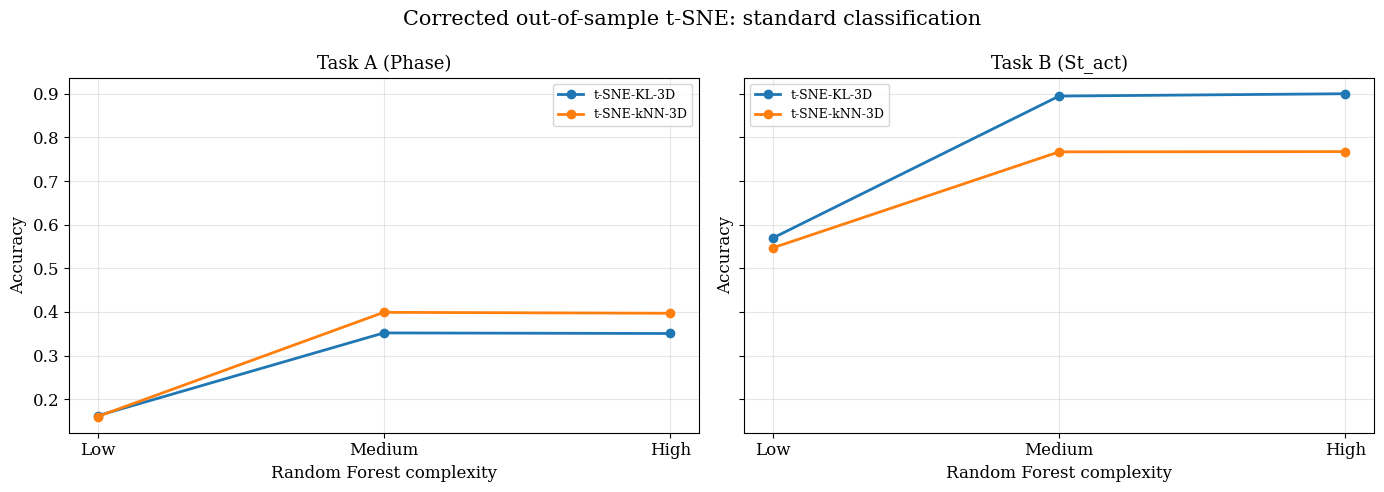

In [47]:
# Plot Tasks A and B, where accuracy is the common metric.
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, task_name in zip(axes, ['A (Phase)', 'B (St_act)']):
    df_task = df_std[df_std['task'] == task_name]
    for rep_name in df_task['representation'].unique():
        df_rep = df_task[df_task['representation'] == rep_name]
        ax.plot(
            df_rep['complexity'],
            df_rep['accuracy'],
            marker='o',
            linewidth=2,
            label=rep_name
        )
    ax.set_xlabel('Random Forest complexity', fontsize=12)
    ax.set_ylabel('Accuracy', fontsize=12)
    ax.set_title(f'Task {task_name}', fontsize=13)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

fig.suptitle('Corrected out-of-sample t-SNE: standard classification', fontsize=15)
plt.tight_layout()
plt.savefig('figures/ml_tsne_oos_standard_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

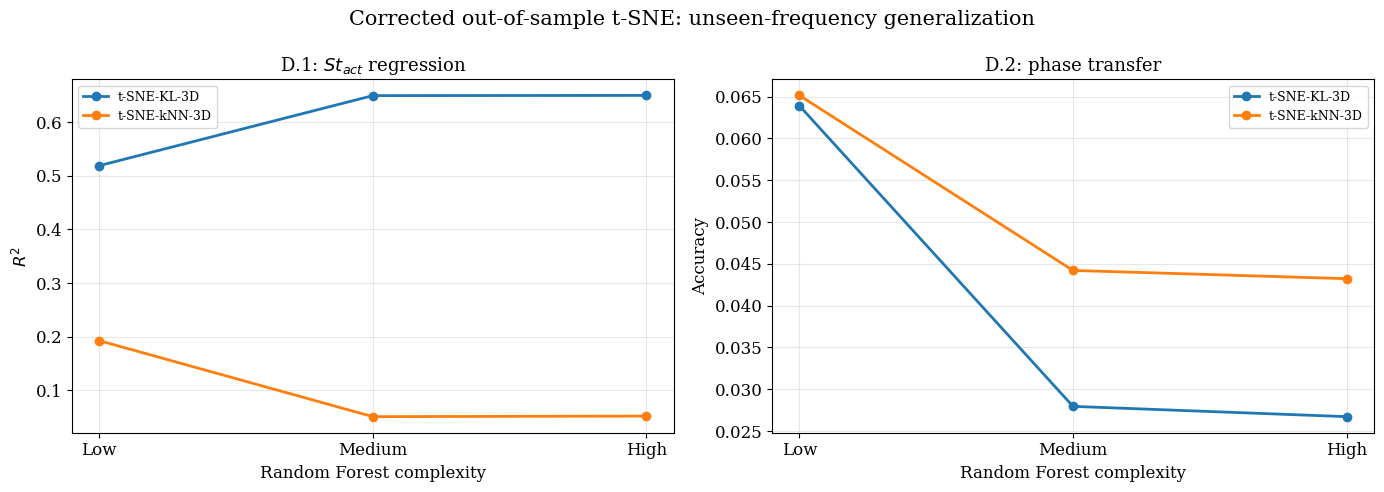

In [48]:
# Plot Task D metrics: R2 for frequency regression and accuracy for phase transfer.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metric_specs = [
    ('D.1 (St regression)', 'r2', '$R^2$', 'D.1: $St_{act}$ regression'),
    ('D.2 (Phase transfer)', 'accuracy', 'Accuracy', 'D.2: phase transfer'),
]

for ax, (task_name, metric, ylabel, title) in zip(axes, metric_specs):
    df_task = df_gen[df_gen['task'] == task_name]
    for rep_name in df_task['representation'].unique():
        df_rep = df_task[df_task['representation'] == rep_name]
        ax.plot(
            df_rep['complexity'],
            df_rep[metric],
            marker='o',
            linewidth=2,
            label=rep_name
        )
    ax.set_xlabel('Random Forest complexity', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

fig.suptitle('Corrected out-of-sample t-SNE: unseen-frequency generalization', fontsize=15)
plt.tight_layout()
plt.savefig('figures/ml_tsne_oos_generalization.png', dpi=300, bbox_inches='tight')
plt.show()